# Inférence — autoencodeur supervisé micro-Doppler

Visualisation rapide du modèle entraîné par `train.py`.

- Charge le checkpoint `results/best.pt` (config embarquée).
- Courbes d'entraînement depuis `results/history.csv`.
- Matrice de confusion sur ~100 fenêtres équilibrées du jeu train.
- Reconstruction visuelle sur **3** exemples.

Pré-requis : avoir lancé au moins une fois `python AICalibration/train.py`.

In [60]:
from pathlib import Path
import sys
import random

import numpy as np
import torch
import matplotlib.pyplot as plt

# Localise la racine du dépôt depuis le notebook AICalibration/inference.ipynb.
_NB_DIR = Path.cwd()
REPO_ROOT = _NB_DIR.parent if _NB_DIR.name == 'AICalibration' else _NB_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from AICalibration.dataset import CalibrationDataset
from AICalibration.model import SpectrogramAutoencoder

print('Repo root :', REPO_ROOT)
print('PyTorch   :', torch.__version__, '| CUDA dispo :', torch.cuda.is_available())

Repo root : /home/zhoul/IoT_radar
PyTorch   : 2.11.0+cu130 | CUDA dispo : True


## Chargement du checkpoint et reconstruction du modèle

La config utilisée à l'entraînement est sauvegardée dans le `.pt` ; on la réutilise telle quelle pour instancier le même modèle.

In [61]:
CKPT_PATH = REPO_ROOT / 'AICalibration' / 'results' / 'best.pt'
assert CKPT_PATH.is_file(), f'Checkpoint introuvable : {CKPT_PATH}.\nLancer d\'abord `python AICalibration/train.py`.'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
cfg = ckpt['config']

model = SpectrogramAutoencoder.from_config(cfg).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print('Checkpoint :', CKPT_PATH)
print('Epoch      :', ckpt.get('epoch'))
print('Best %s = %.4f' % (ckpt.get('best_metric', 'val_total'), ckpt.get('best_value', float("nan"))))
print('Device     :', device)
print('Latent     :', model.latent_shape, ' | Entrée :', model.expected_input_shape)

Checkpoint : /home/zhoul/IoT_radar/AICalibration/results/best.pt
Epoch      : 19
Best val_total = 0.2957
Device     : cuda
Latent     : (128, 32, 2)  | Entrée : (1, 8192, 32)


## Courbes d'entraînement

Si `output.save_metrics: true` dans `config.yaml`, `train.py` append les métriques dans `results/history.csv`.  
Le tracé ci-dessous n'utilise que le **dernier run** (epochs repartant de 1).

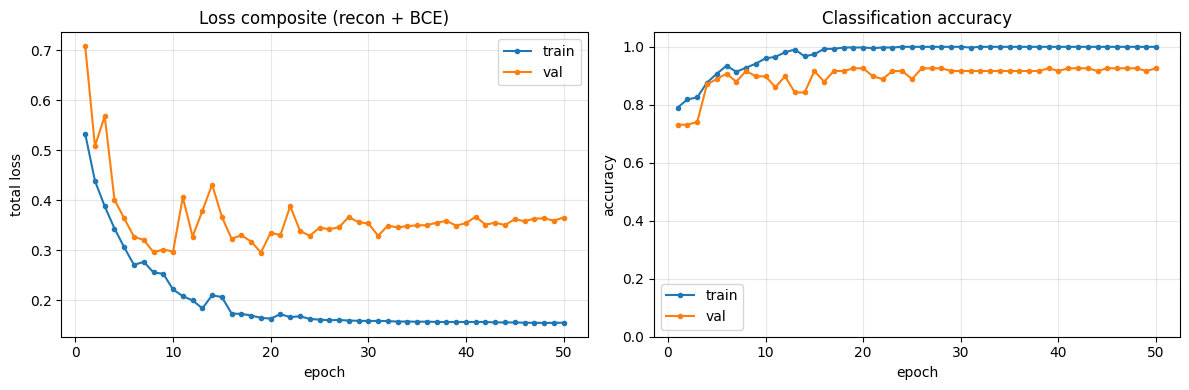

In [62]:
import csv

HISTORY_PATH = REPO_ROOT / 'AICalibration' / 'results' / 'history.csv'

def _last_training_run(rows: list[dict]) -> list[dict]:
    """Keep the latest run when history.csv contains several appended trainings."""
    if not rows:
        return rows
    last_start = 0
    for i, row in enumerate(rows):
        if int(row['epoch']) == 1:
            last_start = i
    return rows[last_start:]

if not HISTORY_PATH.is_file():
    print(f"Pas d'historique : {HISTORY_PATH} (lancer train.py avec output.save_metrics: true)")
else:
    with open(HISTORY_PATH, newline='', encoding='utf-8') as fh:
        all_rows = list(csv.DictReader(fh))

    hist = _last_training_run(all_rows)
    if not hist:
        print(f"Historique vide : {HISTORY_PATH}")
    else:
        if len(all_rows) != len(hist):
            print(
                f"Historique : {len(hist)} epochs (dernier run) "
                f"— {len(all_rows) - len(hist)} lignes d'anciens runs ignorées"
            )

        epochs = [int(r['epoch']) for r in hist]
        train_total = [float(r['train_total']) for r in hist]
        val_total = [float(r['val_total']) for r in hist]
        train_acc = [float(r['train_acc']) for r in hist]
        val_acc = [float(r['val_acc']) for r in hist]

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(epochs, train_total, label='train', marker='o', ms=3)
        axes[0].plot(epochs, val_total, label='val', marker='o', ms=3)
        axes[0].set_xlabel('epoch')
        axes[0].set_ylabel('total loss')
        axes[0].set_title('Loss composite (recon + BCE)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(epochs, train_acc, label='train', marker='o', ms=3)
        axes[1].plot(epochs, val_acc, label='val', marker='o', ms=3)
        axes[1].set_xlabel('epoch')
        axes[1].set_ylabel('accuracy')
        axes[1].set_ylim(0, 1.05)
        axes[1].set_title('Classification accuracy')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

## Chargement du dataset et sélection d'échantillons

In [63]:
data_cfg = cfg['data']
data_root = REPO_ROOT / data_cfg['data_root'] if not Path(data_cfg['data_root']).is_absolute() else Path(data_cfg['data_root'])
split_dir = data_root / data_cfg['train_subdir']

import logging
logging.getLogger('AICalibration.dataset').setLevel(logging.ERROR)  # silencieux pour le notebook

ds = CalibrationDataset(
    split_dir,
    n_cols=int(data_cfg['n_cols']),
    stride=int(data_cfg['stride']),
    normalise=bool(data_cfg['normalise']),
)
print(ds.summary())

CalibrationDataset — 538 fenêtres (n_fft=8192, n_cols=32, stride=32)
  label=0 (vide)        : 107
  label=1 (respiration) : 431
  ratio 1/0             : 4.03
  data_dir              : /home/zhoul/IoT_radar/AICalibration/data/train


In [64]:
# Échantillons pour la matrice de confusion (nombreux) et pour les plots de recon (3).
N_EVAL = 100
N_RECON = 3
rng = random.Random(int(cfg.get('seed', 0)))

idx_per_label = {0: [], 1: []}
for i, lbl in enumerate(ds._labels):
    idx_per_label[int(lbl)].append(i)


def _balanced_pick(pool_by_label: dict[int, list], n: int, rng: random.Random) -> list[int]:
    labels = [lbl for lbl in (0, 1) if pool_by_label[lbl]]
    if not labels or n <= 0:
        return []
    base, extra = divmod(n, len(labels))
    picked: list[int] = []
    for i, lbl in enumerate(labels):
        k = min(base + (1 if i < extra else 0), len(pool_by_label[lbl]))
        picked.extend(rng.sample(pool_by_label[lbl], k))
    rng.shuffle(picked)
    return picked


picked_eval = _balanced_pick(idx_per_label, min(N_EVAL, len(ds)), rng)
picked_recon = _balanced_pick(idx_per_label, min(N_RECON, len(ds)), rng)

print(f'Évaluation confusion : {len(picked_eval)} fenêtres')
print('  labels :', [int(ds._labels[i]) for i in picked_eval])
print(f'Reconstruction         : {len(picked_recon)} fenêtres → indices {picked_recon}')
print('  labels :', [int(ds._labels[i]) for i in picked_recon])

Évaluation confusion : 100 fenêtres
  labels : [0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1]
Reconstruction         : 3 fenêtres → indices [32, 224, 496]
  labels : [0, 0, 1]


## Matrice de confusion

Évaluation sur un sous-ensemble équilibré du jeu train (`N_EVAL` fenêtres).

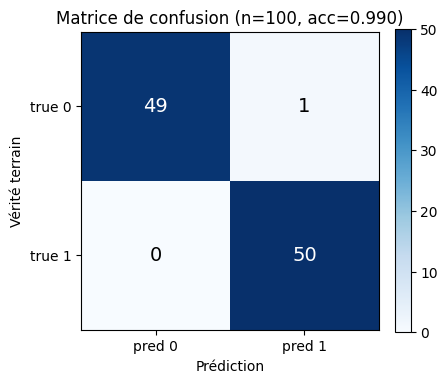

In [65]:
with torch.no_grad():
    xs_eval = torch.stack([ds[i][0] for i in picked_eval]).to(device)
    ys_eval = torch.tensor([int(ds[i][1]) for i in picked_eval], dtype=torch.long)
    _, logits_eval = model(xs_eval)
    probs_eval = torch.sigmoid(logits_eval.squeeze(1)).cpu().numpy()
    preds_eval = (probs_eval >= 0.5).astype(int)
    ys_eval_np = ys_eval.cpu().numpy()

cm = np.zeros((2, 2), dtype=int)
for t, p in zip(ys_eval_np, preds_eval):
    cm[int(t), int(p)] += 1

acc = cm.trace() / max(cm.sum(), 1)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['pred 0', 'pred 1'])
ax.set_yticklabels(['true 0', 'true 1'])
ax.set_xlabel('Prédiction')
ax.set_ylabel('Vérité terrain')
ax.set_title(f'Matrice de confusion (n={len(picked_eval)}, acc={acc:.3f})')
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=14)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Reconstruction — 3 exemples

Entrée vs reconstruction vs carte d'erreur sur `N_RECON` fenêtres équilibrées.

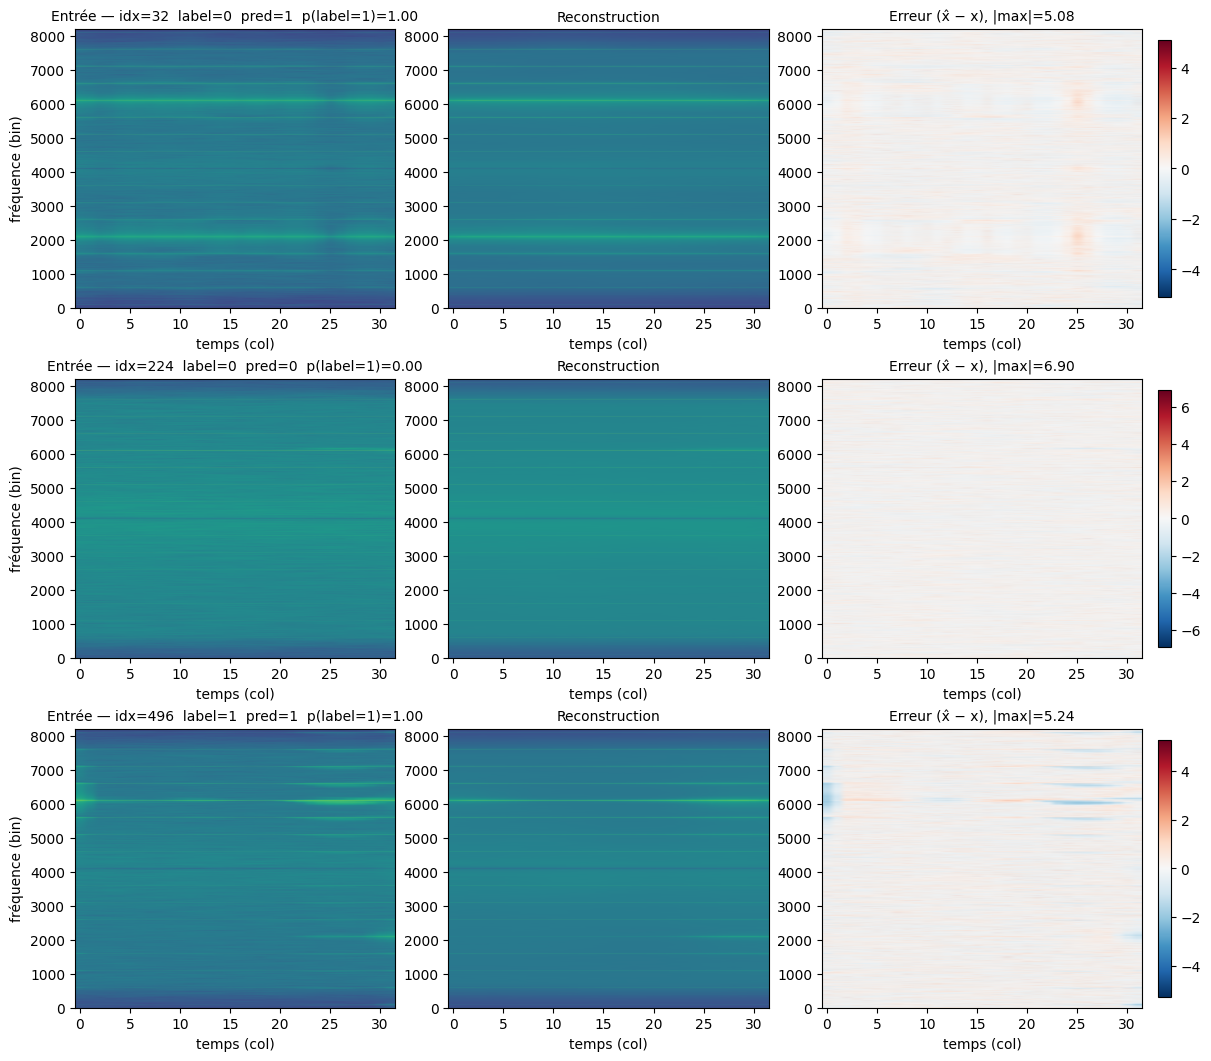

In [66]:
with torch.no_grad():
    xs = torch.stack([ds[i][0] for i in picked_recon]).to(device)
    ys = torch.tensor([int(ds[i][1]) for i in picked_recon], dtype=torch.long)
    x_hat, logits = model(xs)
    probs = torch.sigmoid(logits.squeeze(1)).cpu().numpy()
    preds = (probs >= 0.5).astype(int)

xs_np = xs.squeeze(1).cpu().numpy()
x_hat_np = x_hat.squeeze(1).cpu().numpy()
err_np = x_hat_np - xs_np

n = len(picked_recon)
fig, axes = plt.subplots(n, 3, figsize=(12, 3.5 * n), constrained_layout=True)
if n == 1:
    axes = axes[None, :]

for row in range(n):
    vmin = float(min(xs_np[row].min(), x_hat_np[row].min()))
    vmax = float(max(xs_np[row].max(), x_hat_np[row].max()))
    err_amp = float(np.max(np.abs(err_np[row])))
    title_meta = (
        f"idx={picked_recon[row]}  label={int(ys[row])}  "
        f"pred={int(preds[row])}  p(label=1)={probs[row]:.2f}"
    )

    axes[row, 0].imshow(xs_np[row], aspect='auto', origin='lower', vmin=vmin, vmax=vmax, cmap='viridis')
    axes[row, 0].set_title(f'Entrée — {title_meta}', fontsize=10)
    axes[row, 0].set_xlabel('temps (col)')
    axes[row, 0].set_ylabel('fréquence (bin)')

    axes[row, 1].imshow(x_hat_np[row], aspect='auto', origin='lower', vmin=vmin, vmax=vmax, cmap='viridis')
    axes[row, 1].set_title('Reconstruction', fontsize=10)
    axes[row, 1].set_xlabel('temps (col)')

    im = axes[row, 2].imshow(err_np[row], aspect='auto', origin='lower', vmin=-err_amp, vmax=err_amp, cmap='RdBu_r')
    axes[row, 2].set_title(f'Erreur (x̂ − x), |max|={err_amp:.2f}', fontsize=10)
    axes[row, 2].set_xlabel('temps (col)')
    fig.colorbar(im, ax=axes[row, 2], fraction=0.04)

plt.show()

## Récapitulatif numérique

MSE de reconstruction par échantillon et probabilité de classification.

In [67]:
mse_per = ((x_hat_np - xs_np) ** 2).mean(axis=(1, 2))
l1_per = np.abs(x_hat_np - xs_np).mean(axis=(1, 2))

print(f"{'idx':>5} | {'label':>5} | {'pred':>4} | {'p(1)':>5} | {'MSE':>7} | {'L1':>7}")
print('-' * 52)
for i, idx in enumerate(picked_recon):
    print(
        f'{idx:>5} | {int(ys[i]):>5} | {int(preds[i]):>4} | '
        f'{probs[i]:>5.2f} | {mse_per[i]:>7.4f} | {l1_per[i]:>7.4f}'
    )

  idx | label | pred |  p(1) |     MSE |      L1
----------------------------------------------------
   32 |     0 |    1 |  1.00 |  0.2192 |  0.3570
  224 |     0 |    0 |  0.00 |  0.3633 |  0.4641
  496 |     1 |    1 |  1.00 |  0.3388 |  0.4455
